In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Importing data
df = pd.read_csv('Airlines+Data.csv')


In [ ]:
# Preprocess the date column
df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')
df.set_index('Month', inplace=True)

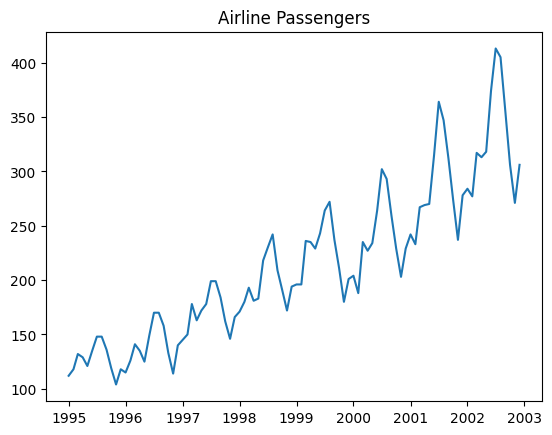

In [ ]:
# Plot the passengers data
plt.plot(df['Passengers'])
plt.title('Airline Passengers')
plt.show()

In [ ]:
# Check stationarity (using Dickey-Fuller test)
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 1.3402479596467138
p-value: 0.9968250481137263


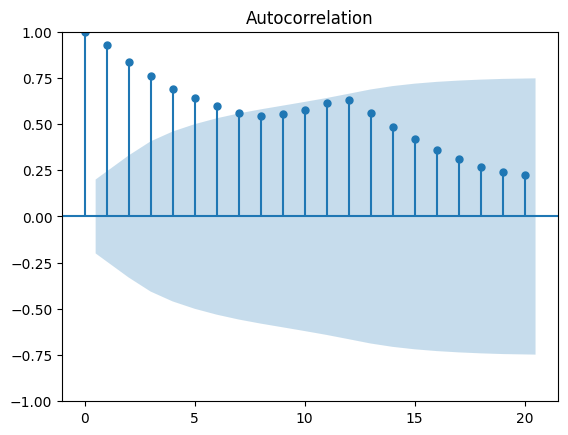

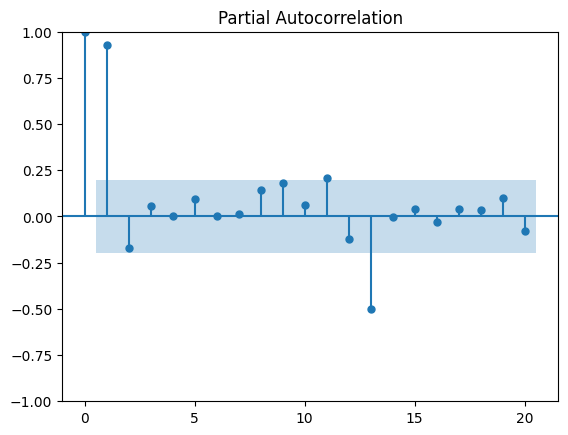

In [ ]:
# Autocorrelation and Partial Autocorrelation Analysis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Passengers'], lags=20)
plt.show()
plot_pacf(df['Passengers'], lags=20)
plt.show()

In [ ]:
p, d, q = 7, 1, 3

In [ ]:
# Fit ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
order = (p, d, q)
model = ARIMA(df['Passengers'], order=order)
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

In [ ]:
# Forecast using the fitted model
forecast_steps = 12
forecast = model_fit.forecast(steps=forecast_steps)

In [ ]:
# Forecast using the fitted model
forecast_steps = 12
forecast = model_fit.forecast(steps=forecast_steps)

In [ ]:
# Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df['Passengers'][-forecast_steps:], forecast, squared=False)
print('Root Mean Squared Error (RMSE):', mse)

Root Mean Squared Error (RMSE): 22.197934146806244


In [ ]:
# Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df['Passengers'][-forecast_steps:], forecast, squared=False)
print('Root Mean Squared Error (RMSE):', mse)

Root Mean Squared Error (RMSE): 22.197934146806244


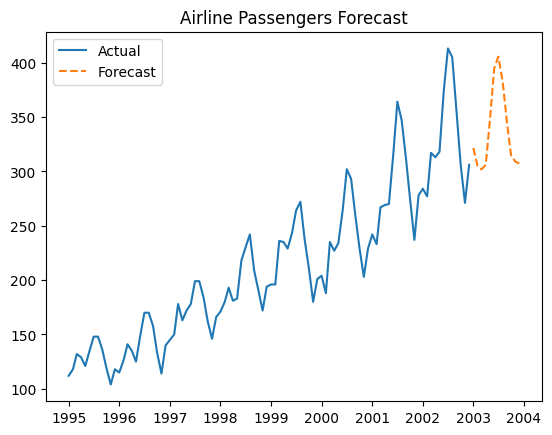

In [ ]:
# Plot actual vs forecasted values
plt.plot(df['Passengers'].index, df['Passengers'], label='Actual')
forecast_index = pd.date_range(start=df['Passengers'].index[-1], periods=forecast_steps, freq='M')
plt.plot(forecast_index, forecast, label='Forecast', linestyle='dashed')
plt.legend()
plt.title('Airline Passengers Forecast')
plt.show()


In [ ]:
# Forecast future months
future_steps = 12
future_forecast = model_fit.forecast(steps=future_steps)

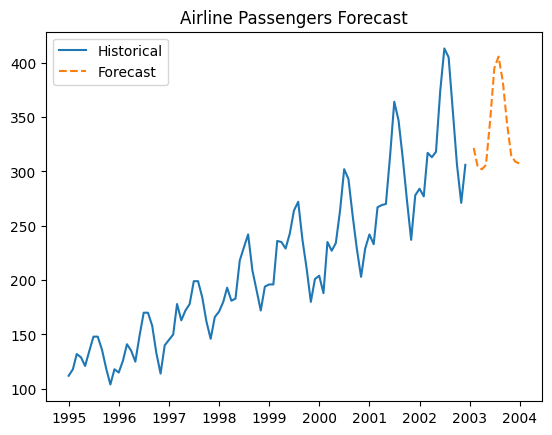

In [ ]:
# Plot the complete forecast
plt.plot(df['Passengers'].index, df['Passengers'], label='Historical')
future_index = pd.date_range(start=df['Passengers'].index[-1] + pd.DateOffset(months=1), periods=future_steps, freq='M')
plt.plot(future_index, future_forecast, label='Forecast', linestyle='dashed')
plt.legend()
plt.title('Airline Passengers Forecast')
plt.show()